# Case 3: corrected asymptotic normality from saved fits

**Prepared only; this notebook has not been executed.** Run cells in order with the repository's Python kernel when analysis is desired. This notebook reads every saved replication in the parent experiment's `run/replications/`, reloads the fitted main network for inference, and reconstructs the original data and split from their saved seeds. It never trains, profiles, or updates a network. All diagnostic tables and figures stay in memory and notebook outputs; there are no result-file writes.

**Question:** does subtracting the fitted empirical score contribution remove the non-vanishing root-sample-size bias, and do the corrected statistics resemble $N(0,1)$? The requested subtraction below is authoritative. No empirical recentering or rescaling is used to make a plot look normal.

Reuse: `../psi_n_if_helpers.py` supplies data reconstruction, checkpoint restoration, training predictions, the exact Case 3 projection, and the empirical score. It loads whitelisted definitions from the original DGP notebook through the existing source bridge; it does not run those notebooks. Its high-level diagnostics are not called, because they also perform profiling and independent-sample calculations that are unnecessary here.

## Definitions and the sample-size convention

Directory names and the column `n` denote the **full generated sample size** $n_{\mathrm{full}}$. Following `root_n_train_error_*` in `asymptotic_normality_case3.ipynb` and `fill_terms` in the existing helper, all sums and square-root scaling here use **$N=n_{\mathrm{train}}=\lfloor0.8n_{\mathrm{full}}\rfloor$** and only the original training observations. The validation observations do not enter the score or covariance. Thus $N=400,800,1600,3200$ for the saved full-sample grid.

On raw, unstandardized $Z$, put $S(Z)=\sum_{k=1}^{8}\Phi^{-1}(Z_k/2)$. The homoscedastic Case 3 oracle quantities are
$$
\varphi^*(Z)=
\begin{pmatrix}\Phi(S/\sqrt{45})\\2\Phi(S/\sqrt{126})\end{pmatrix},
\qquad f(0)=f_{t_3}(0)=\frac{2}{\pi\sqrt3},
\qquad \theta_0=(1,-1)^\top,\quad \tau=\tfrac12 .
$$
With $\widetilde X_i=X_i-\varphi^*(Z_i)$, define
$$
\begin{aligned}
r_i&=Y_i-X_i^\top\hat\theta-\hat m(Z_i),\\
\Psi_N&=-\frac1N\sum_{i\in\mathcal I_{\mathrm{train}}}
          [\tau-\mathbf1\{r_i<0\}]\widetilde X_i,\\
M_N&=\frac1N\sum_{i\in\mathcal I_{\mathrm{train}}}\widetilde X_i\widetilde X_i^\top,
\quad \Sigma_2=f(0)M_N,\quad \Sigma_1=\tau(1-\tau)M_N,\\
A_N&=\sqrt N(\hat\theta-\theta_0),\qquad
B_N=\Sigma_2^{-1}\sqrt N\Psi_N,\qquad C_N=A_N-B_N,\\
V_N&=\Sigma_2^{-1}\Sigma_1\Sigma_2^{-1}.
\end{aligned}
$$
The indicator is strictly $r_i<0$, including the leading minus sign in the score. $M_N$ is the **uncentered second moment with divisor $N$** specified in this diagnostic, not the centered $N-1$ covariance used in the earlier primary Oracle A comparison. The full two-dimensional matrices retain off-diagonal terms.

Here $C_N$ means the corrected root-$N$ error, not the differently defined `adam_C_n_*` orthogonality term in the older IF diagnostic.

## Standardization and coverage

The requested standardized vector is $Z_C=V_N^{-1/2}C_N$, using the **symmetric positive-definite inverse square root**. The raw comparison is $Z_A=V_N^{-1/2}A_N$. Whitening can mix the original coefficients; its coordinates are labelled accordingly.

For inference on an individual original coefficient, also compute
$$
T_{C,j}=\frac{C_{N,j}}{\sqrt{V_{N,jj}}},\quad
T_{A,j}=\frac{A_{N,j}}{\sqrt{V_{N,jj}}},\quad
\hat\theta^{\,\mathrm{corr}}=\hat\theta-\frac{B_N}{\sqrt N}.
$$
Empirical corrected 95% coverage is the fraction of saved replications satisfying
$$
\theta_{0j}\in
\left[\hat\theta_j^{\,\mathrm{corr}}
\ \pm\ \Phi^{-1}(0.975)\sqrt{V_{N,jj}/N}\right],
$$
equivalently $|T_{C,j}|\le\Phi^{-1}(0.975)$. It is coefficient-wise coverage, not simultaneous vector coverage. $V_N$ is the covariance for a root-$N$ statistic; divide by $N$ for estimator variance.

Both whitening and marginal standardization are reported and plotted. Neither subtracts the empirical mean or divides by an empirical Monte Carlo SD. Epoch settings remain separate, since they reuse paired datasets and are different estimators.

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import importlib.util
import itertools
import json
import platform
import sys
import time

# Keep imports from producing bytecode files in the existing experiment.
sys.dont_write_bytecode = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import torch
from IPython.display import display

ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "dqAux.py").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start the kernel in the repository or this notebook's folder.")
EXPERIMENT = ROOT / "results" / "2026-09-11_asymptotic_normality_case3"
RUN = EXPERIMENT / "run"
HELPER_PATH = EXPERIMENT / "psi_n_if_helpers.py"

config = json.loads((RUN / "run_config.json").read_text(encoding="utf-8"))
identity = config["identity"]
spec = importlib.util.spec_from_file_location("case3_corrected_score_helpers", HELPER_PATH)
diag = importlib.util.module_from_spec(spec)
spec.loader.exec_module(diag)

THETA_0 = diag.THETA_0.copy()
TAU = float(diag.TAU)
F0 = float(diag.ORACLE_F0)
CRITICAL = float(norm.ppf(0.975))
assert identity["case"] == diag.CASE == 3
assert identity["tau"] == TAU == 0.5
assert identity["seed"] == diag.BASE_SEED
assert identity["train_fraction"] == diag.TRAIN_FRACTION == 0.8
assert [identity["hp"]["depth"], identity["hp"]["width"]] == diag.NET_NODES
np.testing.assert_array_equal(identity["theta"], THETA_0)
np.testing.assert_allclose(F0, 2 / (np.pi * np.sqrt(3)), rtol=1e-14)
np.testing.assert_allclose(diag.true_phi_star_case3(np.ones((1, 8))), [[0.5, 1.0]])

# Verify the source files that determine reconstruction and network inference.
source_names = (
    "dqAux.py",
    "results/2026-09-10-asymptotic-normality/source_bridge.py",
    "results/2026-09-04-homoscedastic-simulation/simulate_homoscedastic.ipynb",
)
saved_source_hashes = {name.replace("\\", "/"): digest
                       for name, digest in identity["sources"].items()}
source_hashes = {}
for name in source_names:
    digest = hashlib.sha256((ROOT / name).read_bytes()).hexdigest()
    if digest != saved_source_hashes.get(name):
        raise ValueError(f"Source differs from the saved run: {name}")
    source_hashes[name] = digest

_, bridge, original = diag.load_stack(EXPERIMENT)
torch.set_num_threads(int(identity["threads"]))
torch.use_deterministic_algorithms(bool(identity["deterministic_algorithms"]))
print(f"Oracle f(0) = {F0:.12f}; all scaling uses the original training sample.")

Oracle f(0) = 0.367552596948; all scaling uses the original training sample.


## Inventory and reproducibility checks

Use every complete saved replication, with no replication cap and no automatic dropping of failures. Missing checkpoint/result pairs, source changes, mismatched seeds/hashes, incompatible settings, nonfinite values, or singular matrices stop the calculation with the offending path. Data reconstruction includes the original error draws before reconstructing the training permutation; the SHA-256 comparison checks the full $X,Z,Y$ arrays and that permutation.

The helper restores the saved post-clipping main-network state, including its masks, and evaluates it in evaluation mode without gradients. Its `predict_train` returns $\hat m=\hat q-X^\top\hat\theta$, preserving the existing IF diagnostic's fitted-residual convention. No new nuisance estimation, residual-density estimation, auxiliary projection fit, or external R call is needed.

In [2]:
replication_root = RUN / "replications"
directories = sorted(p for p in replication_root.glob("n_*_epochs_*_rep_*") if p.is_dir())
if not directories:
    raise FileNotFoundError(f"No saved replications under {replication_root}")

incomplete = [
    str(p.relative_to(EXPERIMENT))
    for p in directories
    if not all((p / name).is_file() for name in ("fits.pt", "result.json"))
]
if incomplete:
    raise FileNotFoundError(f"Incomplete saved replication pairs: {incomplete[:10]}")

available = diag.list_available(EXPERIMENT)
if len(available) != len(directories) or len(set(available)) != len(available):
    raise ValueError("Directory inventory is inconsistent or contains duplicate settings.")
if config.get("status") == "complete":
    expected = set(itertools.product(
        config["sample_sizes"], config["epoch_counts"],
        range(1, int(config["requested_Q"]) + 1),
    ))
    if set(available) != expected:
        raise ValueError("Saved replication keys do not match the completed run configuration.")
    if len(available) != int(config["completed_rows"]):
        raise ValueError("Saved replication count does not match run_config.json.")

inventory = pd.DataFrame(available, columns=["n", "epochs", "rep"])
inventory["n_train"] = (inventory["n"] * diag.TRAIN_FRACTION).astype(int)
inventory = inventory.sort_values(["n", "rep", "epochs"]).reset_index(drop=True)
display(
    inventory.groupby(["n", "n_train", "epochs"], as_index=False)
    .agg(saved_replications=("rep", "size"))
    .sort_values(["epochs", "n"])
)

provenance = {
    "run_fingerprint": config["fingerprint"],
    "run_config_sha256": hashlib.sha256((RUN / "run_config.json").read_bytes()).hexdigest(),
    "helper_sha256": hashlib.sha256(HELPER_PATH.read_bytes()).hexdigest(),
    "source_sha256": source_hashes,
    "python": platform.python_version(),
    "versions": {name: importlib.metadata.version(name)
                 for name in ("numpy", "pandas", "scipy", "scikit-learn",
                              "torch", "torchtuples", "matplotlib")},
    "sample_size_convention": "N = n_train; n labels full generated sample size",
    "moment_convention": "uncentered Xtilde.T @ Xtilde / N",
    "standardization": "symmetric matrix whitening and marginal oracle SD",
    "replication_count": len(inventory),
    "exclusions": [],
}
display(pd.Series(provenance, name="provenance"))

,n,n_train,epochs,saved_replications
0,500,400,200,200
3,1000,800,200,200
6,2000,1600,200,200
9,4000,3200,200,200
1,500,400,500,200
4,1000,800,500,200
7,2000,1600,500,200
10,4000,3200,500,200
2,500,400,1000,200
5,1000,800,1000,200


run_fingerprint           ae01061c4ed6dfccbaf6d09ff63f72b0de57dc5d27e13f...
run_config_sha256         8ccf4da0c59f18a0772577bc83db0e08b03f49451a10e4...
helper_sha256             fecef13843de32f124e6c69a31acb3dd534cb307627f55...
source_sha256             {'dqAux.py': '99dc7ce752818cd59e4a8d8cc048d0a3...
python                                                               3.11.9
versions                  {'numpy': '2.4.6', 'pandas': '3.0.5', 'scipy':...
sample_size_convention     N = n_train; n labels full generated sample size
moment_convention                          uncentered Xtilde.T @ Xtilde / N
standardization           symmetric matrix whitening and marginal oracle SD
replication_count                                                      2400
exclusions                                                               []
Name: provenance, dtype: object

In [3]:
def require_spd(matrix, name):
    """Validate a finite symmetric positive-definite matrix; never regularize it."""
    matrix = np.asarray(matrix, dtype=np.float64)
    if matrix.shape != (2, 2) or not np.isfinite(matrix).all():
        raise ValueError(f"{name}: invalid 2-by-2 matrix")
    np.testing.assert_allclose(matrix, matrix.T, rtol=0, atol=1e-12)
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    if eigenvalues[0] <= np.finfo(float).eps * eigenvalues[-1]:
        raise np.linalg.LinAlgError(f"{name}: singular or numerically nonpositive")
    return eigenvalues, eigenvectors


def oracle_geometry(data):
    """Training-sample moment, oracle sandwich, and symmetric whitening matrix."""
    z_raw = np.asarray(data.z_train, dtype=float)
    if not np.isfinite(z_raw).all() or np.any((z_raw < 0) | (z_raw > 2)):
        raise ValueError("Oracle projection requires raw Z in [0, 2].")
    phi = diag.true_phi_star_case3(z_raw)
    x_tilde = np.asarray(data.x_train, dtype=float) - phi
    N = len(data.y_train)
    moment = (x_tilde.T @ x_tilde) / N
    moment_eigenvalues, _ = require_spd(moment, "M_N")
    sigma2 = F0 * moment
    sigma1 = TAU * (1 - TAU) * moment

    # Two solves implement Sigma2^{-1} Sigma1 Sigma2^{-1}.
    left = np.linalg.solve(sigma2, sigma1)
    V = np.linalg.solve(sigma2, left.T).T
    V = (V + V.T) / 2
    eigenvalues, eigenvectors = require_spd(V, "V_N")
    inverse_sqrt = (eigenvectors * (1 / np.sqrt(eigenvalues))) @ eigenvectors.T

    # Independent algebraic identity and whitening check.
    V_closed = TAU * (1 - TAU) / F0**2 * np.linalg.solve(moment, np.eye(2))
    np.testing.assert_allclose(V, V_closed, rtol=1e-10, atol=1e-12)
    np.testing.assert_allclose(inverse_sqrt @ V @ inverse_sqrt, np.eye(2),
                               rtol=1e-10, atol=1e-10)
    return {
        "x_tilde": x_tilde, "N": N, "sigma1": sigma1, "sigma2": sigma2,
        "V": V, "inverse_sqrt": inverse_sqrt,
        "moment_min_eigenvalue": float(moment_eigenvalues[0]),
        "moment_condition": float(moment_eigenvalues[-1] / moment_eigenvalues[0]),
    }


def corrected_replication(data, geometry, n, epochs, rep):
    """Read one saved main fit and return one record per original coefficient."""
    path = diag.replication_dir(EXPERIMENT, n, epochs, rep)
    result = json.loads((path / "result.json").read_text(encoding="utf-8"))
    row = result["row"]
    fits = torch.load(path / "fits.pt", map_location="cpu", weights_only=True)
    setting = {"n": n, "epochs": epochs, "rep": rep}
    if fits["setting"] != setting or any(row[k] != value for k, value in setting.items()):
        raise ValueError("Saved setting does not match the directory key.")
    if not (fits["fingerprint"] == result["fingerprint"] == config["fingerprint"]):
        raise ValueError("Checkpoint/result/run fingerprints disagree.")
    if not (fits["data_sha256"] == row["data_sha256"] == data.data_sha256):
        raise ValueError("Reconstructed data do not match the saved hashes.")
    if row["data_seed"] != data.data_seed or row["fit_seed"] != data.fit_seed:
        raise ValueError("Reconstructed seeds do not match the saved seeds.")
    if row["case"] != 3 or row["tau"] != TAU or row["method"] != "DPLQR":
        raise ValueError("Unexpected saved DGP or estimator.")
    N = geometry["N"]
    if row["n_train"] != N or row["n_val"] != len(data.y_val):
        raise ValueError("Training/validation sample sizes disagree.")
    if N != int(diag.TRAIN_FRACTION * n):
        raise ValueError("Training-sample convention differs from the original analysis.")

    main = fits["stages"]["main"]
    if main["seed"] != data.fit_seed or main["epochs_run"] != epochs:
        raise ValueError("Main checkpoint is not the completed requested fit.")
    net = diag.load_main_net(main["state"])  # Restores parameters and calls eval().
    with torch.no_grad():
        theta, m_hat, prediction = diag.predict_train(net, data)
    saved_theta = np.array([row[f"theta_hat_{j}"] for j in (1, 2)])
    np.testing.assert_allclose(theta, saved_theta, rtol=0, atol=1e-7)
    np.testing.assert_array_equal([row[f"theta_0_{j}"] for j in (1, 2)], THETA_0)
    for value in (theta, m_hat, prediction):
        if not np.isfinite(value).all():
            raise FloatingPointError("Nonfinite saved-fit prediction or coefficient.")

    residual = data.y_train - data.x_train @ theta - m_hat
    np.testing.assert_allclose(residual, data.y_train - prediction,
                               rtol=1e-12, atol=1e-12)
    x_tilde = geometry["x_tilde"]
    psi = diag.mean_psi(residual, x_tilde, tau=TAU)
    # Direct form checks the leading minus sign and strict indicator convention.
    np.testing.assert_allclose(
        psi, (x_tilde.T @ ((residual < 0).astype(float) - TAU)) / N,
        rtol=1e-12, atol=1e-14,
    )

    root_N = np.sqrt(N)
    A = root_N * (theta - THETA_0)
    B = np.linalg.solve(geometry["sigma2"], root_N * psi)
    C = A - B
    V = geometry["V"]
    Z_A = geometry["inverse_sqrt"] @ A
    Z_C = geometry["inverse_sqrt"] @ C
    marginal_sd = np.sqrt(np.diag(V))
    T_A, T_C = A / marginal_sd, C / marginal_sd
    theta_corrected = theta - B / root_N
    se_oracle = marginal_sd / root_N
    lower = theta_corrected - CRITICAL * se_oracle
    upper = theta_corrected + CRITICAL * se_oracle
    covered_C = (lower <= THETA_0) & (THETA_0 <= upper)
    covered_A = np.abs(T_A) <= CRITICAL

    np.testing.assert_allclose(A, [row[f"root_n_train_error_{j}"] for j in (1, 2)],
                               rtol=1e-10, atol=1e-10)
    np.testing.assert_allclose(C, root_N * (theta_corrected - THETA_0),
                               rtol=1e-10, atol=1e-10)
    np.testing.assert_array_equal(covered_C, np.abs(T_C) <= CRITICAL)
    if not np.isfinite(np.concatenate((A, B, C, Z_A, Z_C, T_A, T_C))).all():
        raise FloatingPointError("Nonfinite diagnostic statistic.")

    common = {
        "n": n, "n_train": N, "epochs": epochs, "rep": rep,
        "data_seed": data.data_seed, "fit_seed": data.fit_seed,
        "data_sha256": data.data_sha256, "f0": F0,
        "moment_min_eigenvalue": geometry["moment_min_eigenvalue"],
        "moment_condition": geometry["moment_condition"],
        "residual_zero_count": int(np.count_nonzero(residual == 0)),
    }
    for name in ("sigma1", "sigma2", "V"):
        matrix = geometry[name]
        common.update({f"{name}_11": float(matrix[0, 0]),
                       f"{name}_12": float(matrix[0, 1]),
                       f"{name}_22": float(matrix[1, 1])})
    records = []
    for k in range(2):
        records.append({
            **common, "coefficient": k + 1,
            "theta_hat": float(theta[k]), "theta_corrected": float(theta_corrected[k]),
            "psi": float(psi[k]), "A": float(A[k]), "B": float(B[k]), "C": float(C[k]),
            "Z_A": float(Z_A[k]), "Z_C": float(Z_C[k]),
            "T_A": float(T_A[k]), "T_C": float(T_C[k]),
            "oracle_variance_root_N": float(V[k, k]),
            "oracle_se_theta": float(se_oracle[k]),
            "corrected_ci_lower": float(lower[k]), "corrected_ci_upper": float(upper[k]),
            "covered_A": bool(covered_A[k]), "covered_C": bool(covered_C[k]),
        })
    return records

## Calculate from saved fits

This is the only analysis loop. It reconstructs each distinct $(n_{\mathrm{full}},\mathrm{rep})$ dataset once, reuses its oracle geometry across the saved epoch settings, and performs forward prediction only. Any failure stops the loop rather than silently changing the analyzed replication set. This cell has not been run during notebook creation.

In [4]:
started = time.perf_counter()
records = []
completed_fits = 0
for (n, rep), settings in inventory.groupby(["n", "rep"], sort=True):
    n, rep = int(n), int(rep)
    try:
        data = diag.regenerate(original, n, rep)
        geometry = oracle_geometry(data)
    except Exception as exc:
        raise RuntimeError(f"Reconstruction/geometry failed for n={n}, rep={rep}") from exc
    for epochs in settings["epochs"].sort_values():
        epochs = int(epochs)
        try:
            records.extend(corrected_replication(data, geometry, n, epochs, rep))
        except Exception as exc:
            path = diag.replication_dir(EXPERIMENT, n, epochs, rep)
            raise RuntimeError(f"Diagnostic failed at {path}") from exc
        completed_fits += 1
        if completed_fits % 100 == 0 or completed_fits == len(inventory):
            print(f"Read {completed_fits}/{len(inventory)} saved fits")

results = pd.DataFrame.from_records(records).sort_values(
    ["epochs", "n", "rep", "coefficient"]
).reset_index(drop=True)
assert len(results) == 2 * len(inventory)
assert not results.duplicated(["n", "epochs", "rep", "coefficient"]).any()
np.testing.assert_allclose(results["C"], results["A"] - results["B"],
                           rtol=1e-12, atol=1e-12)
provenance["analysis_seconds"] = time.perf_counter() - started
print(f"Completed {completed_fits} saved fits in {provenance['analysis_seconds']:.1f} seconds.")
print("Detailed per-replication records are in 'results'; no files were written.")
display(results.head())

Read 100/2400 saved fits
Read 200/2400 saved fits
Read 300/2400 saved fits
Read 400/2400 saved fits
Read 500/2400 saved fits
Read 600/2400 saved fits
Read 700/2400 saved fits
Read 800/2400 saved fits
Read 900/2400 saved fits
Read 1000/2400 saved fits
Read 1100/2400 saved fits
Read 1200/2400 saved fits
Read 1300/2400 saved fits
Read 1400/2400 saved fits
Read 1500/2400 saved fits
Read 1600/2400 saved fits
Read 1700/2400 saved fits
Read 1800/2400 saved fits
Read 1900/2400 saved fits
Read 2000/2400 saved fits
Read 2100/2400 saved fits
Read 2200/2400 saved fits
Read 2300/2400 saved fits
Read 2400/2400 saved fits
Completed 2400 saved fits in 37.0 seconds.
Detailed per-replication records are in 'results'; no files were written.


,n,n_train,epochs,rep,data_seed,fit_seed,data_sha256,f0,moment_min_eigenvalue,moment_condition,...,Z_A,Z_C,T_A,T_C,oracle_variance_root_N,oracle_se_theta,corrected_ci_lower,corrected_ci_upper,covered_A,covered_C
0,500,400,200,1,50760905,51260905,07186b455866b49073d60cc9802ff5f48c8881aeb8da4a...,0.367553,0.160693,1.221373,...,-2.658435,-1.096100,-2.819558,-1.254921,10.574084,0.162589,0.477295,1.114632,False,True
1,500,400,200,1,50760905,51260905,07186b455866b49073d60cc9802ff5f48c8881aeb8da4a...,0.367553,0.160693,1.221373,...,3.326409,3.241228,3.454910,3.291881,10.370808,0.161019,-0.785536,-0.154355,False,False
2,500,400,200,2,50760906,51260906,0b662ac19523ed2889b3077c71c9d322b6c1ac2d4368d5...,0.367553,0.162451,1.329469,...,-2.124555,-1.701197,-2.210294,-1.788170,11.009705,0.165904,0.378168,1.028501,False,True
3,500,400,200,2,50760906,51260906,0b662ac19523ed2889b3077c71c9d322b6c1ac2d4368d5...,0.367553,0.162451,1.329469,...,1.906359,1.923300,2.012635,2.007879,8.950121,0.149584,-0.992833,-0.406475,False,False
4,500,400,200,3,50760907,51260907,272be430285a9081050cf3428e716df06250ce566272b3...,0.367553,0.161220,1.276705,...,-3.092053,-2.475122,-3.226762,-2.655739,10.759952,0.164012,0.242970,0.885885,False,False


## Summary for every sample size, epoch setting, and coefficient

`mean_A`, `mean_B`, `mean_C`, and `sd_C` are in root-training-sample units. `mean_Z_C` and `sd_Z_C` describe coordinates of the requested matrix-whitened $V_N^{-1/2}C_N$; `mean_T_C` and `sd_T_C` describe marginal standardization of the original coefficient. The table also supplies raw standardization and raw coverage for comparison.

All SDs use the across-replication divisor $Q-1$. Mean Monte Carlo SEs are $\mathrm{SD}/\sqrt Q$, and coverage Monte Carlo SEs use $\sqrt{\hat p(1-\hat p)/Q}$. These quantify simulation uncertainty within each setting; results across epoch settings are paired, not independent.

In [5]:
def mcse_mean(values):
    return values.std(ddof=1) / np.sqrt(len(values))


summary = (
    results.groupby(["epochs", "n", "n_train", "coefficient"], as_index=False)
    .agg(
        Q=("rep", "size"),
        mean_A=("A", "mean"), mean_B=("B", "mean"), mean_C=("C", "mean"),
        sd_C=("C", "std"),
        mcse_A=("A", mcse_mean), mcse_B=("B", mcse_mean), mcse_C=("C", mcse_mean),
        mean_Z_A=("Z_A", "mean"), sd_Z_A=("Z_A", "std"),
        mean_Z_C=("Z_C", "mean"), sd_Z_C=("Z_C", "std"),
        mcse_Z_C=("Z_C", mcse_mean),
        mean_T_A=("T_A", "mean"), sd_T_A=("T_A", "std"),
        mean_T_C=("T_C", "mean"), sd_T_C=("T_C", "std"),
        mcse_T_C=("T_C", mcse_mean),
        coverage_raw_95=("covered_A", "mean"),
        coverage_corrected_95=("covered_C", "mean"),
        max_moment_condition=("moment_condition", "max"),
    )
    .sort_values(["epochs", "n", "coefficient"])
    .reset_index(drop=True)
)
np.testing.assert_allclose(summary["mean_C"], summary["mean_A"] - summary["mean_B"],
                           rtol=1e-10, atol=1e-10)
summary["mcse_coverage_corrected"] = np.sqrt(
    summary["coverage_corrected_95"] * (1 - summary["coverage_corrected_95"]) / summary["Q"]
)
summary["mean_C_mc95_lower"] = summary["mean_C"] - CRITICAL * summary["mcse_C"]
summary["mean_C_mc95_upper"] = summary["mean_C"] + CRITICAL * summary["mcse_C"]

main_columns = [
    "epochs", "n", "n_train", "coefficient", "Q",
    "mean_A", "mean_B", "mean_C", "sd_C",
    "mean_Z_C", "sd_Z_C", "mean_T_C", "sd_T_C",
    "coverage_raw_95", "coverage_corrected_95",
]
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(summary[main_columns].round(4))
    display(summary[[
        "epochs", "n", "coefficient", "Q", "mcse_C",
        "mean_C_mc95_lower", "mean_C_mc95_upper",
        "mcse_Z_C", "mcse_T_C", "mcse_coverage_corrected",
        "max_moment_condition",
    ]].round(5))

,epochs,n,n_train,coefficient,Q,mean_A,mean_B,mean_C,sd_C,mean_Z_C,sd_Z_C,mean_T_C,sd_T_C,coverage_raw_95,coverage_corrected_95
0,200,500,400,1,200,-4.6581,-0.7617,-3.8963,4.3381,-1.1481,1.3330,-1.1987,1.3372,0.680,0.705
1,200,500,400,2,200,6.4929,1.5554,4.9375,4.3738,1.5315,1.3978,1.5729,1.3989,0.455,0.590
2,200,1000,800,1,200,-2.6164,-0.4582,-2.1582,4.1840,-0.6164,1.2859,-0.6614,1.2844,0.840,0.835
3,200,1000,800,2,200,4.4236,0.4956,3.9280,4.2386,1.2276,1.3506,1.2500,1.3490,0.685,0.680
4,200,2000,1600,1,200,-0.6566,-0.3498,-0.3068,4.4255,-0.0728,1.3597,-0.0961,1.3629,0.860,0.855
5,200,2000,1600,2,200,1.9890,0.0369,1.9521,3.6506,0.6203,1.1667,0.6242,1.1703,0.895,0.865
6,200,4000,3200,1,200,-0.7243,-0.0519,-0.6724,3.8223,-0.1998,1.1812,-0.2086,1.1805,0.920,0.890
7,200,4000,3200,2,200,0.7134,-0.1592,0.8726,3.6901,0.2736,1.1813,0.2793,1.1808,0.955,0.870
8,500,500,400,1,200,-3.4428,-0.4956,-2.9472,4.9741,-0.8648,1.5329,-0.9041,1.5300,0.760,0.715
9,500,500,400,2,200,4.3104,0.4819,3.8284,4.5610,1.1898,1.4626,1.2174,1.4606,0.695,0.690


,epochs,n,coefficient,Q,mcse_C,mean_C_mc95_lower,mean_C_mc95_upper,mcse_Z_C,mcse_T_C,mcse_coverage_corrected,max_moment_condition
0,200,500,1,200,0.30675,-4.49756,-3.29513,0.09426,0.09455,0.03225,1.56501
1,200,500,2,200,0.30927,4.33135,5.54368,0.09884,0.09892,0.03478,1.56501
2,200,1000,1,200,0.29585,-2.73801,-1.57829,0.09092,0.09082,0.02625,1.43559
3,200,1000,2,200,0.29971,3.34059,4.51544,0.09550,0.09539,0.03298,1.43559
4,200,2000,1,200,0.31293,-0.92009,0.30658,0.09615,0.09637,0.02490,1.36430
5,200,2000,2,200,0.25813,1.44621,2.45807,0.08250,0.08275,0.02416,1.36430
6,200,4000,1,200,0.27027,-1.20213,-0.14267,0.08352,0.08348,0.02212,1.30580
7,200,4000,2,200,0.26093,0.36118,1.38401,0.08353,0.08349,0.02378,1.30580
8,500,500,1,200,0.35172,-3.63661,-2.25788,0.10840,0.10818,0.03192,1.56501
9,500,500,2,200,0.32251,3.19633,4.46056,0.10342,0.10328,0.03270,1.56501


## Raw versus corrected distributions

For each epoch setting, each figure has one row per full sample size and one column per coordinate. Histograms use common bins spanning **all** raw and corrected observations, with a fixed $N(0,1)$ density overlay. QQ plots compare to standard-normal quantiles with the identity line, not a fitted line.

The first pair of figures uses matrix whitening, as requested. The second pair uses marginal standardization so that the panels correspond directly to the coefficient-wise confidence intervals. Both coefficients and every saved sample size are included.

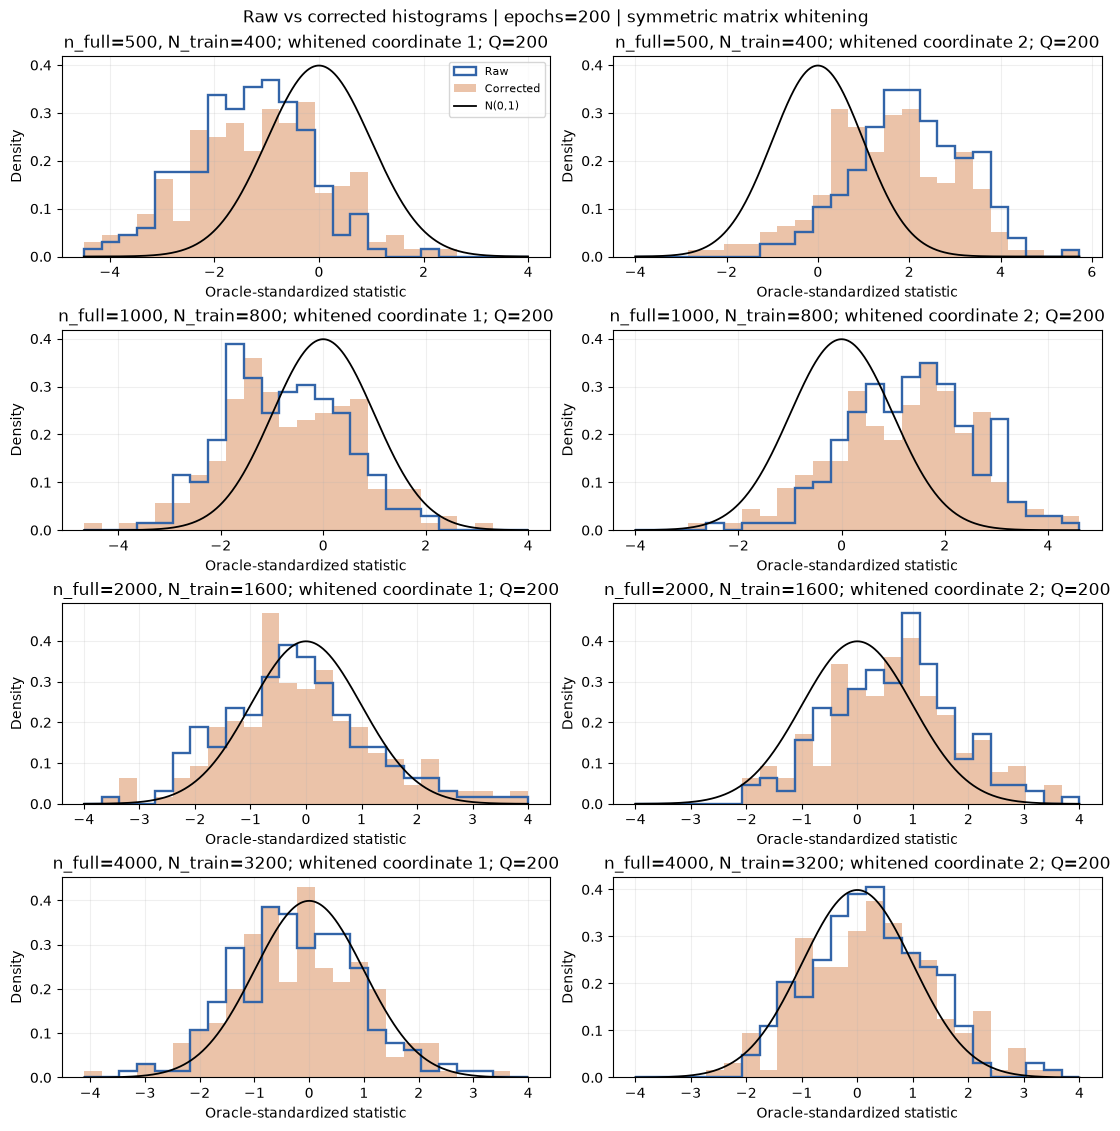

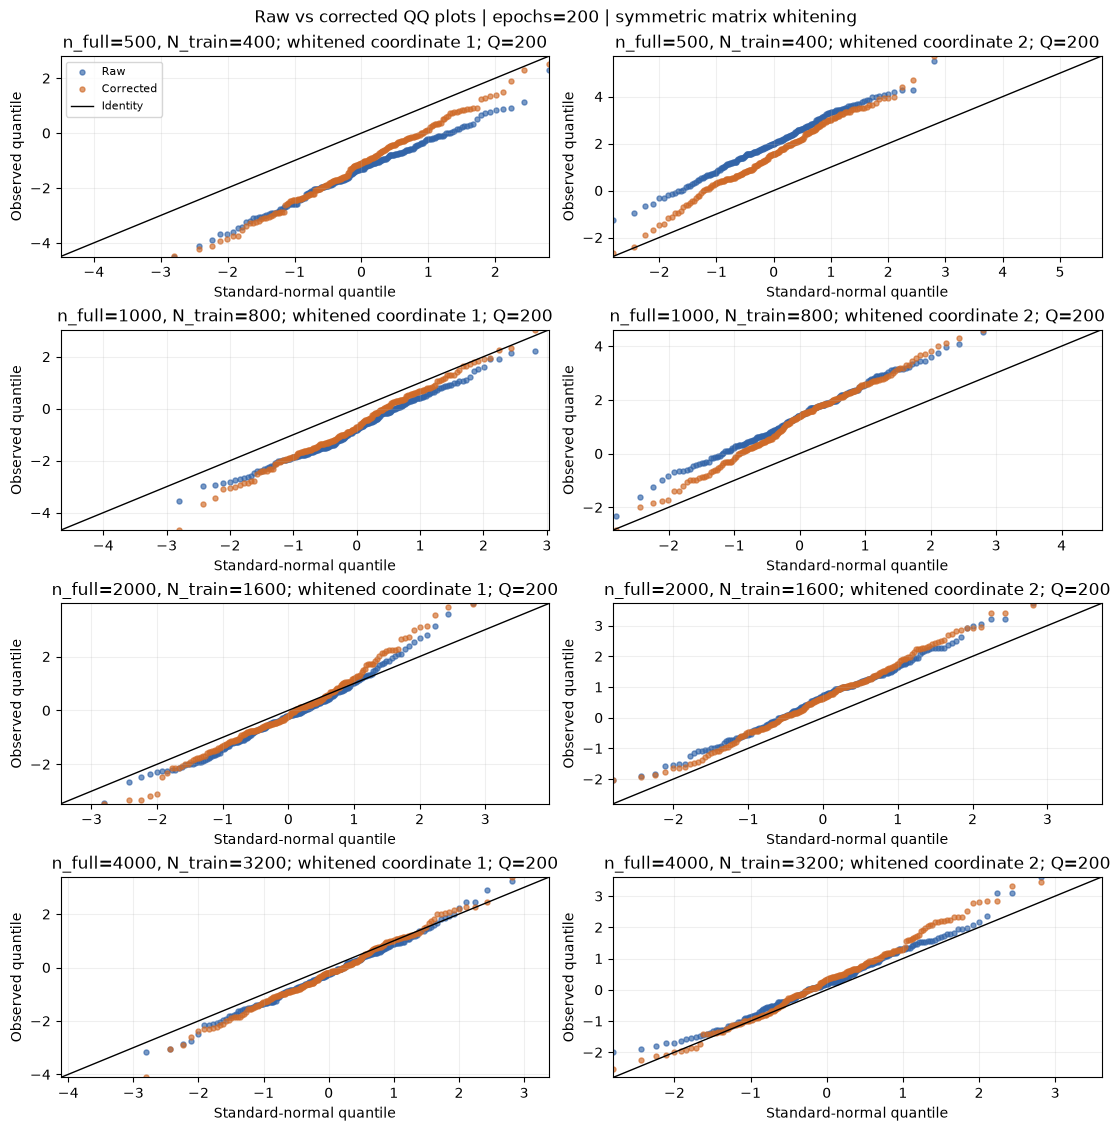

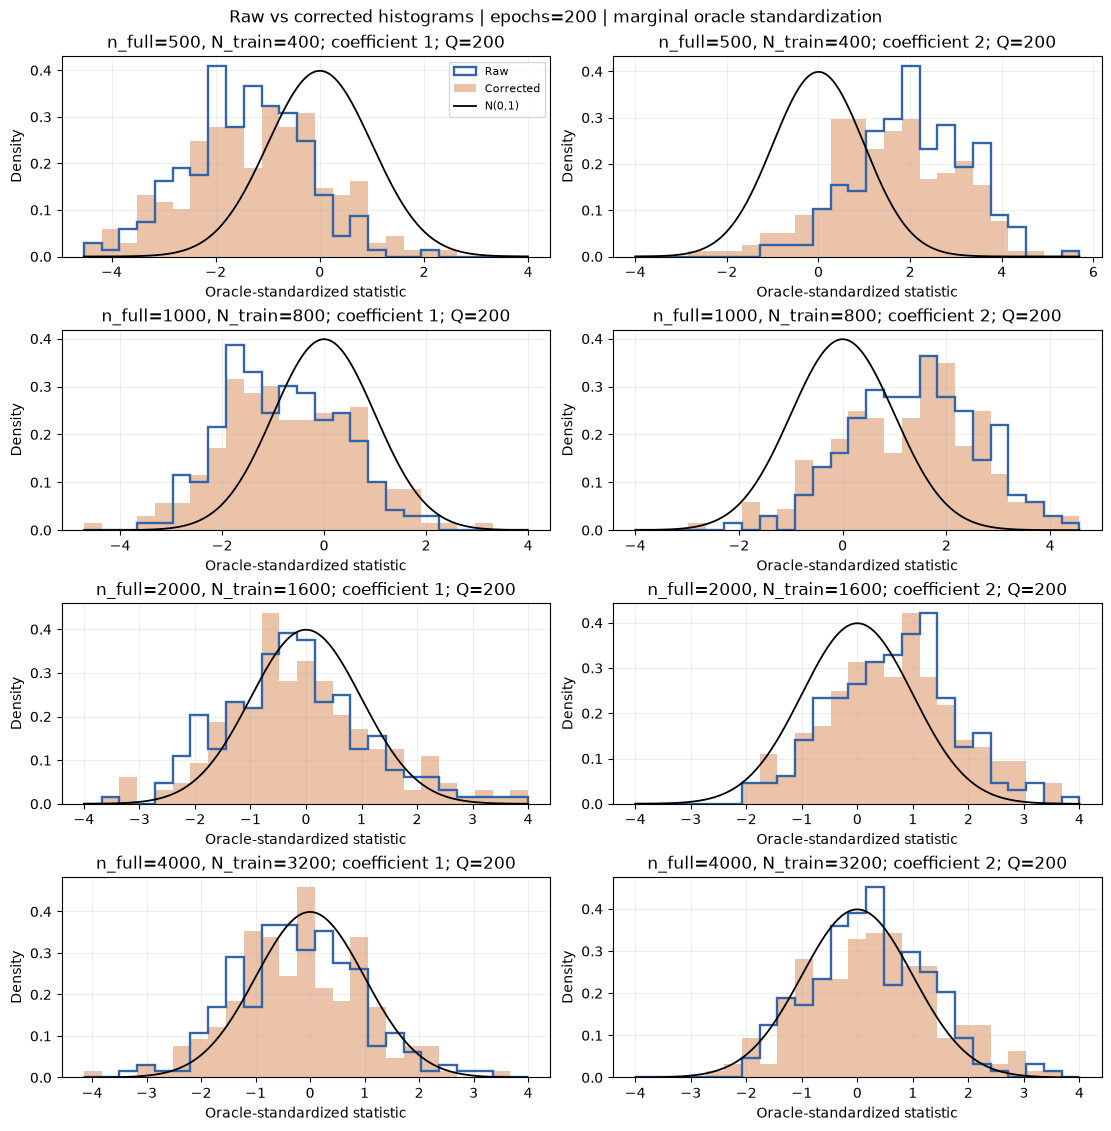

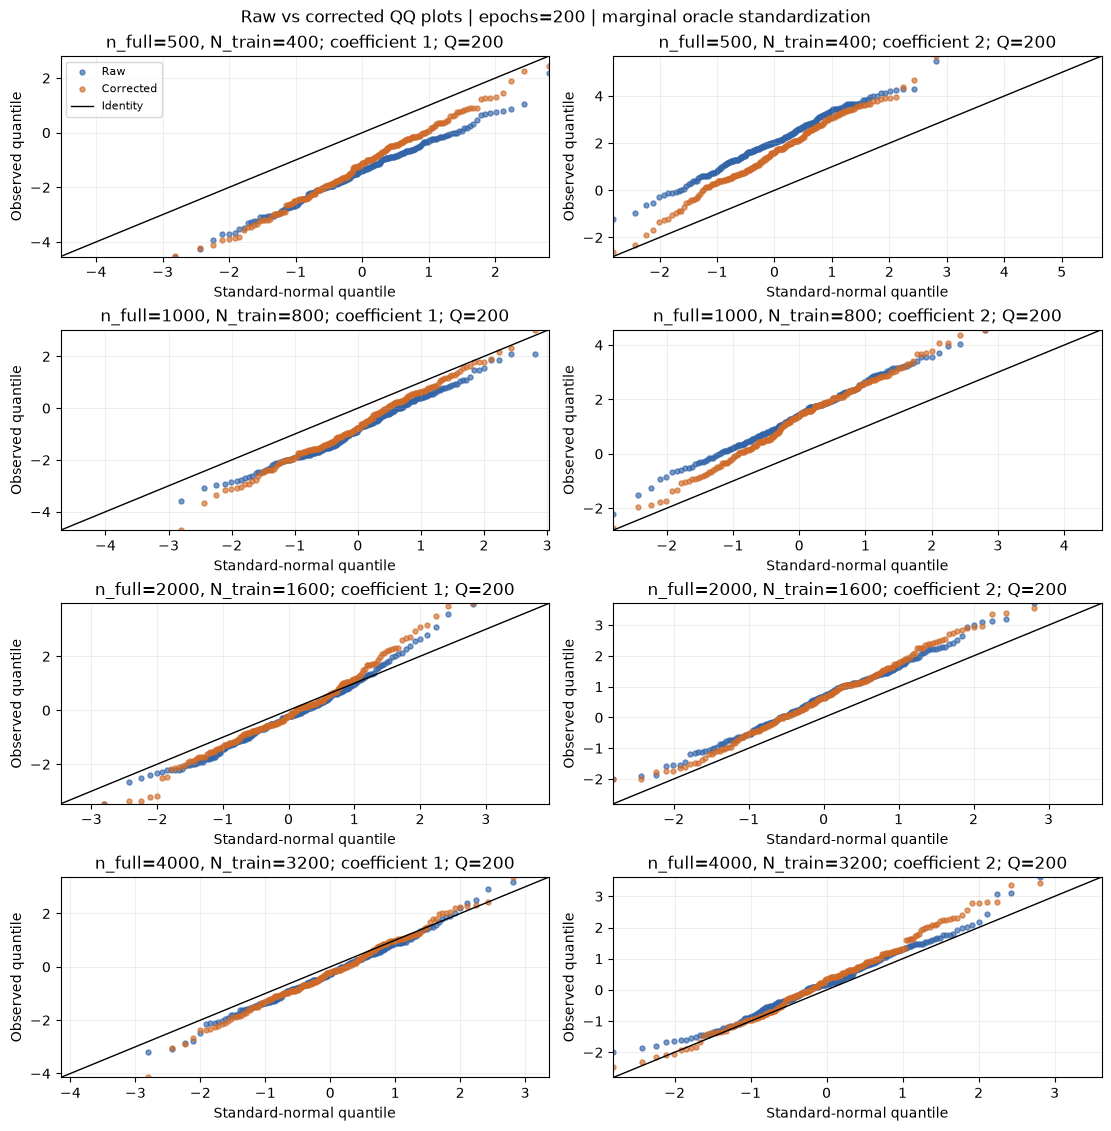

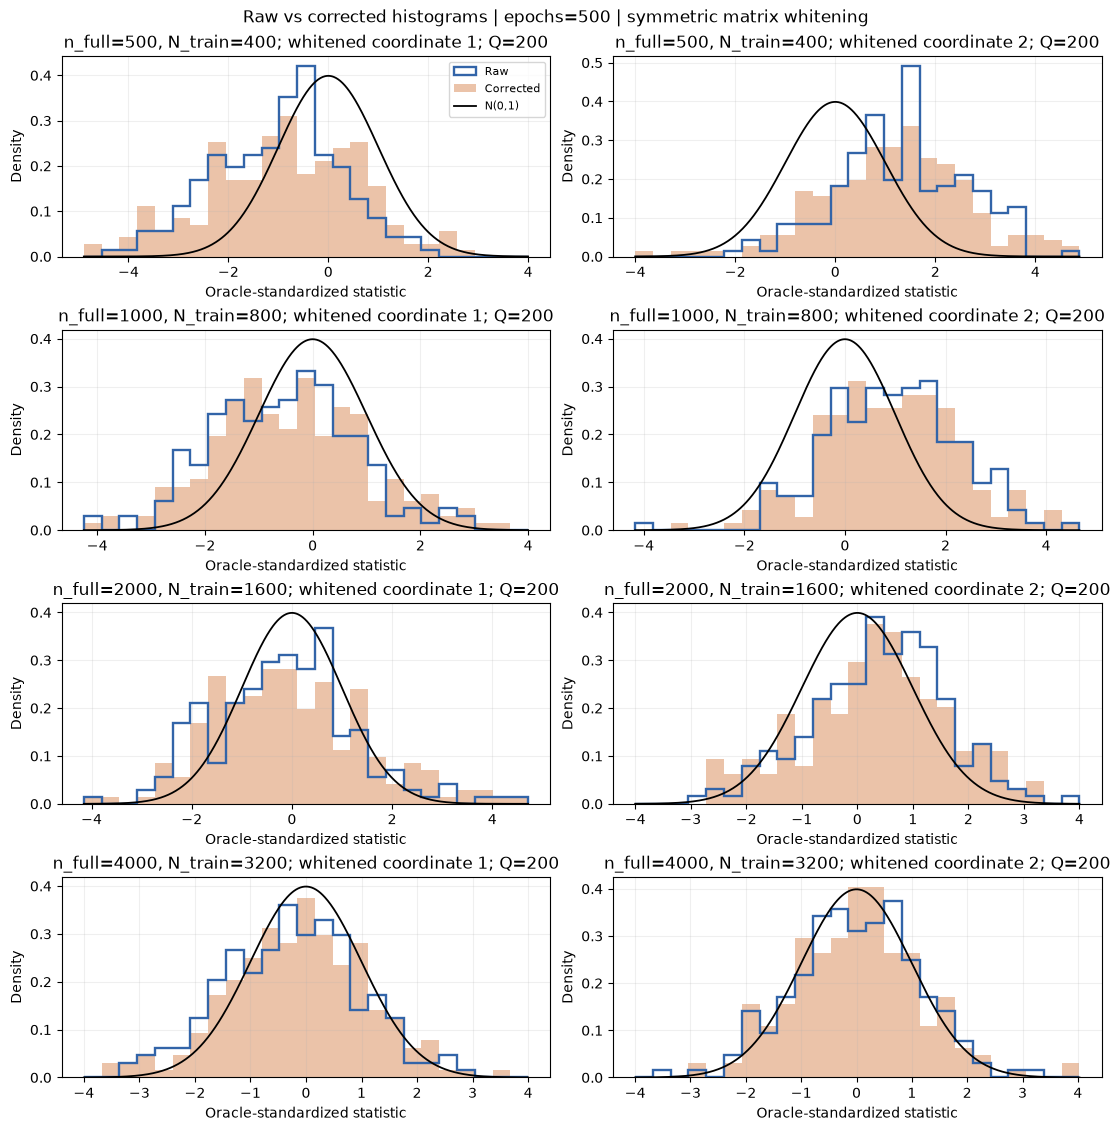

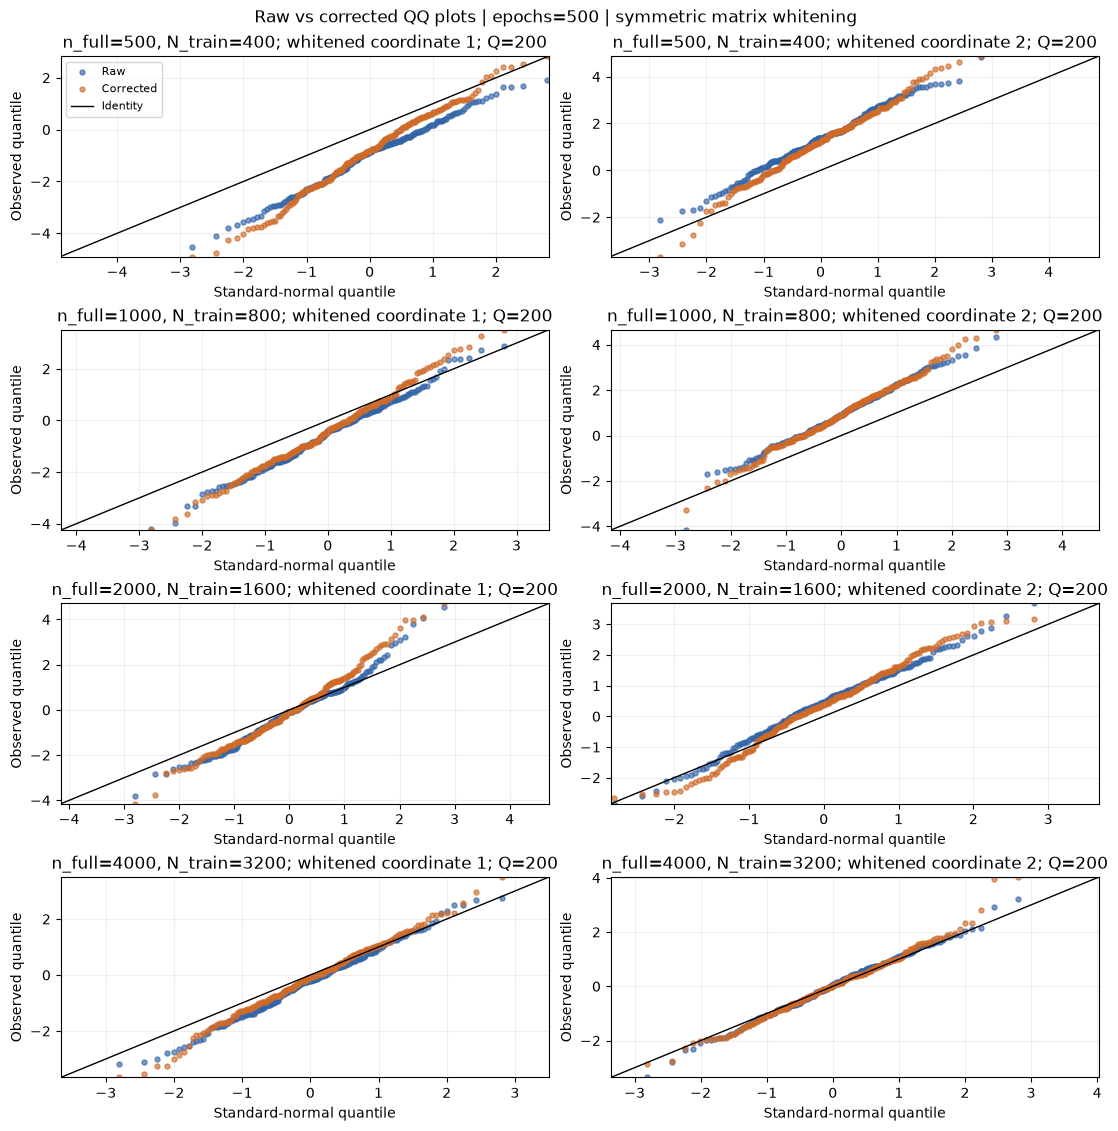

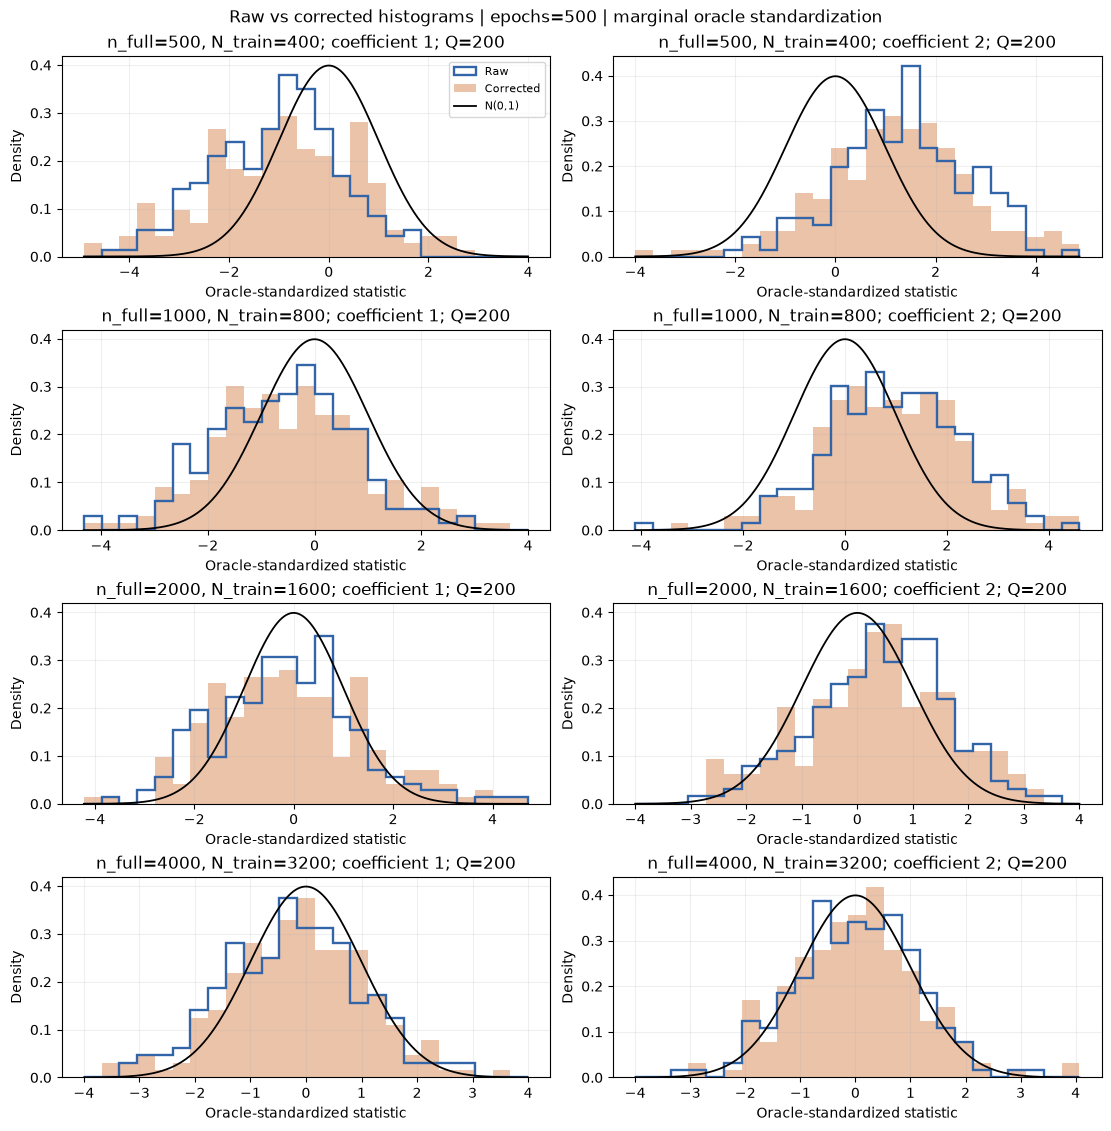

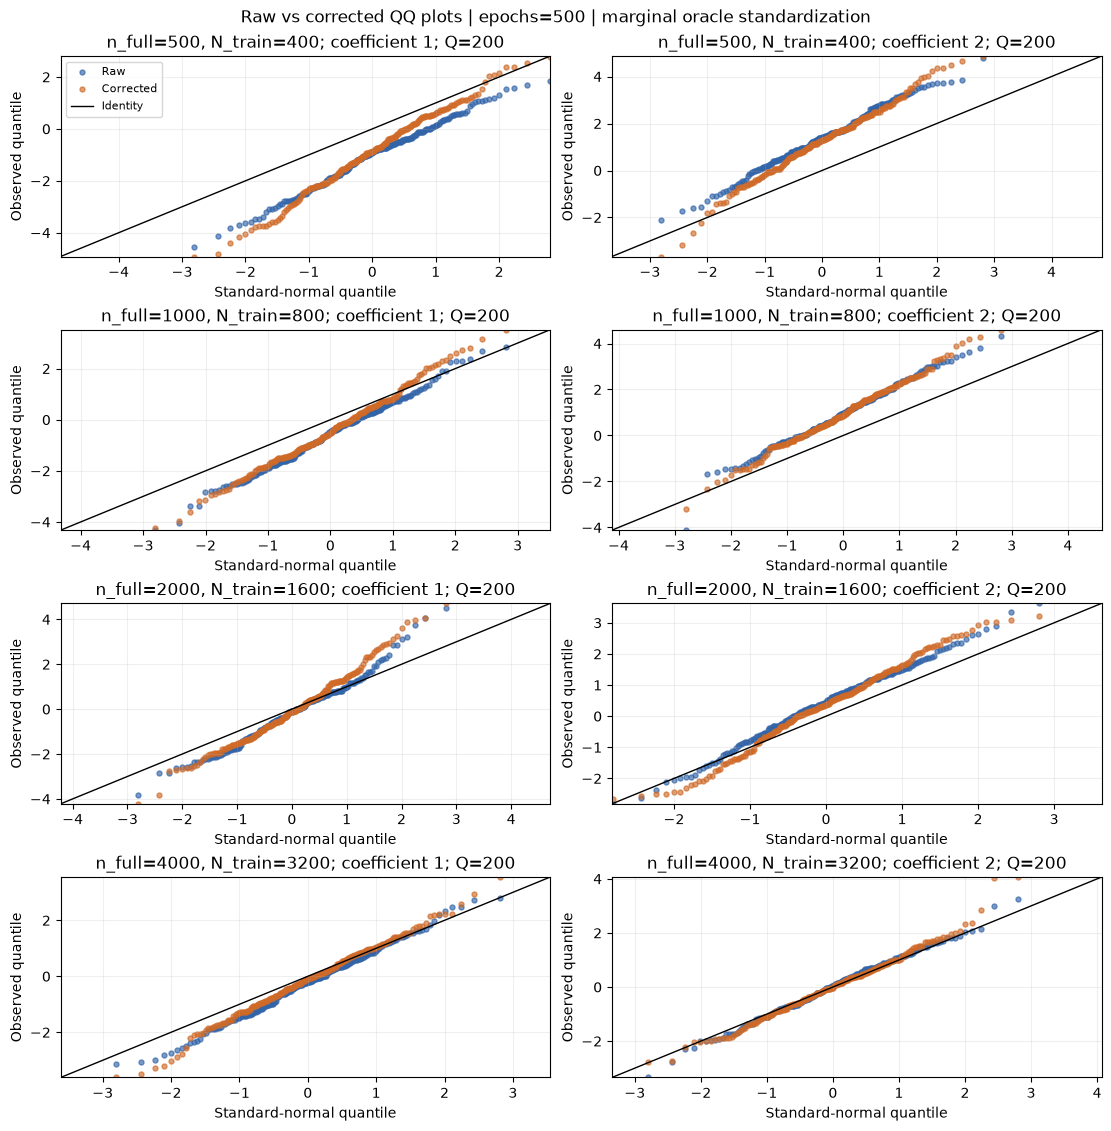

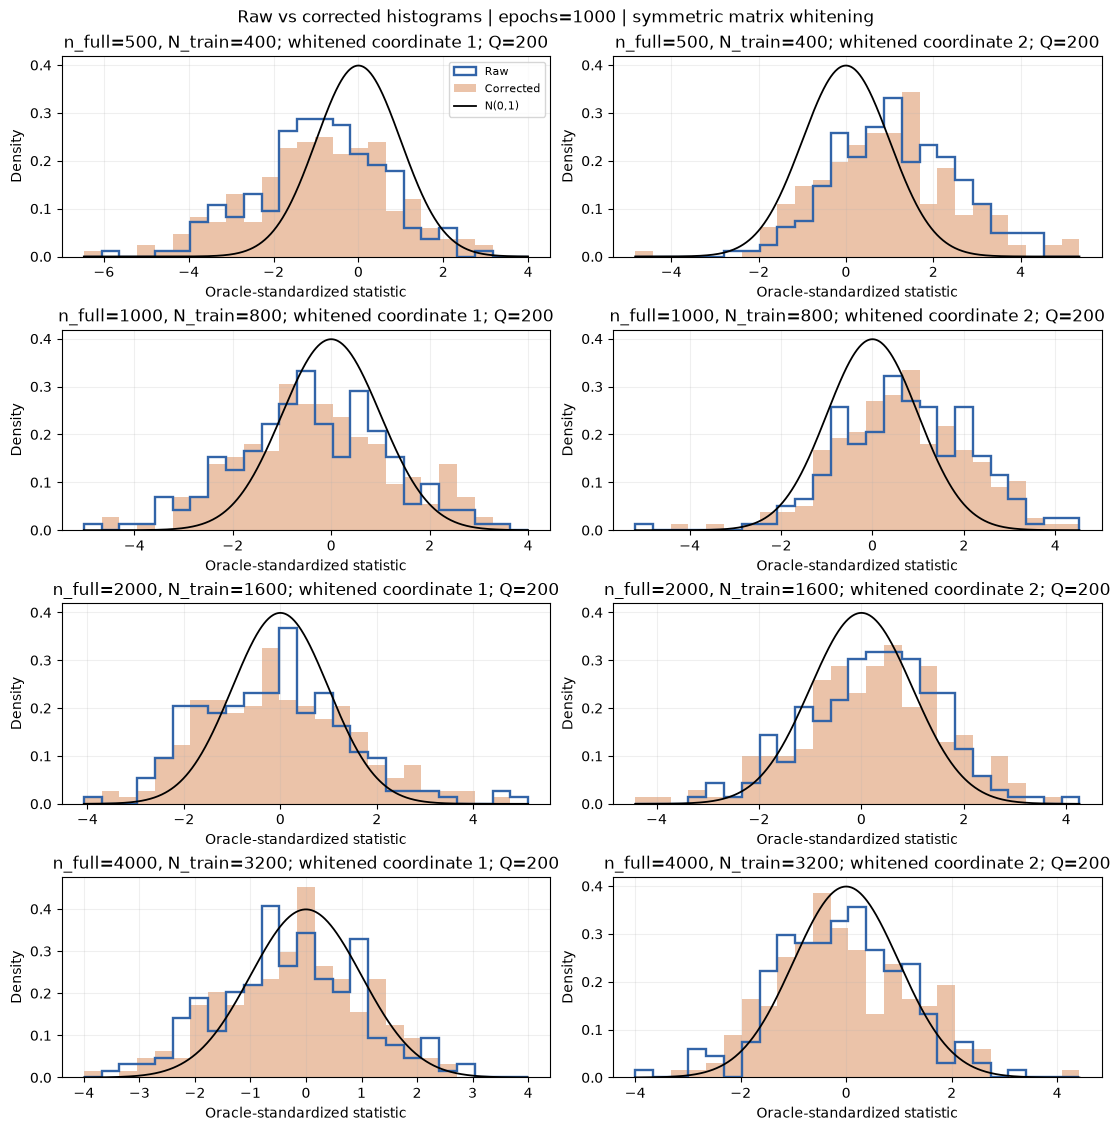

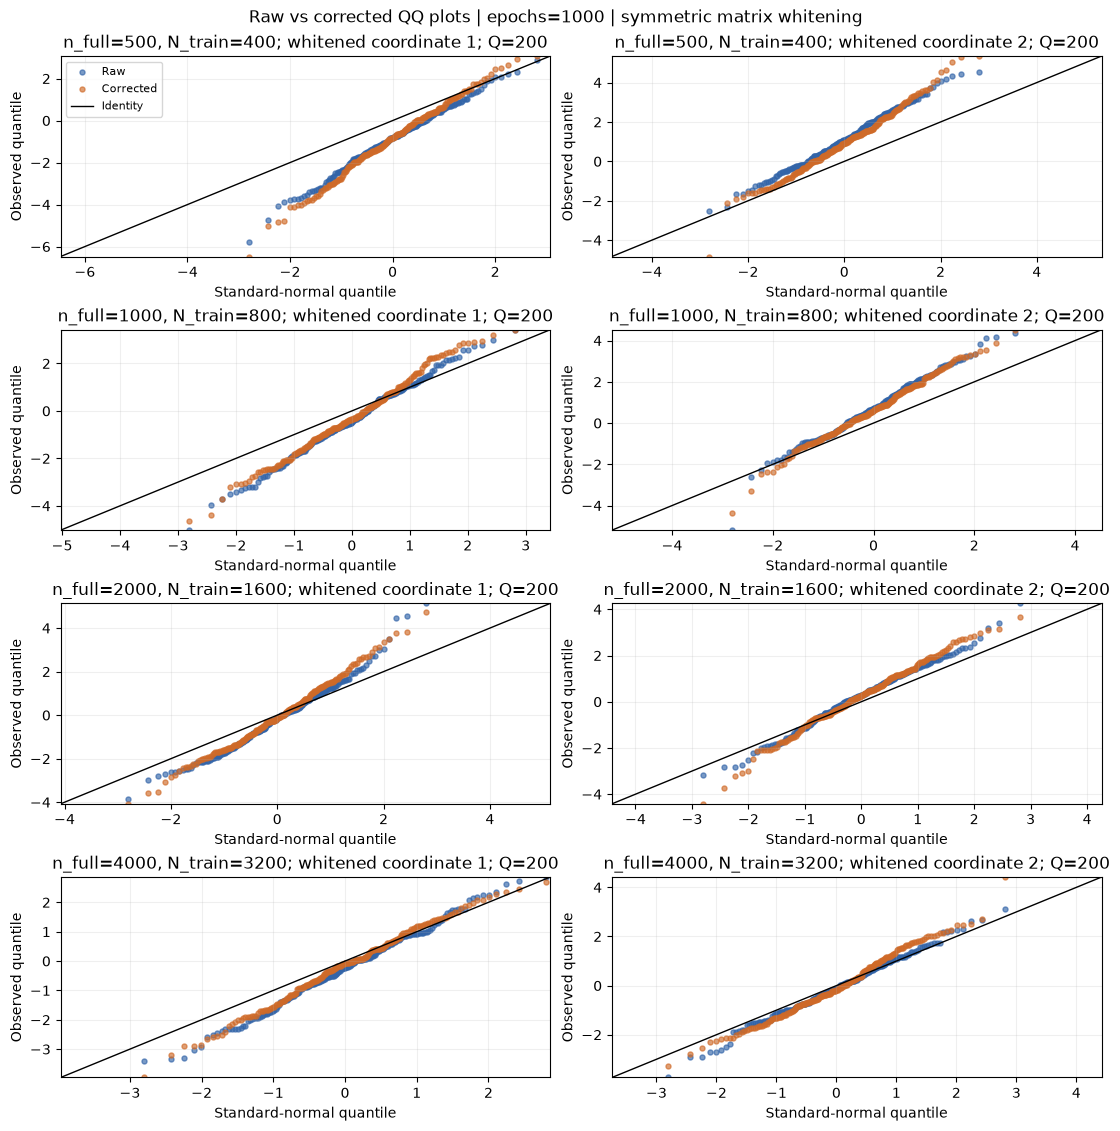

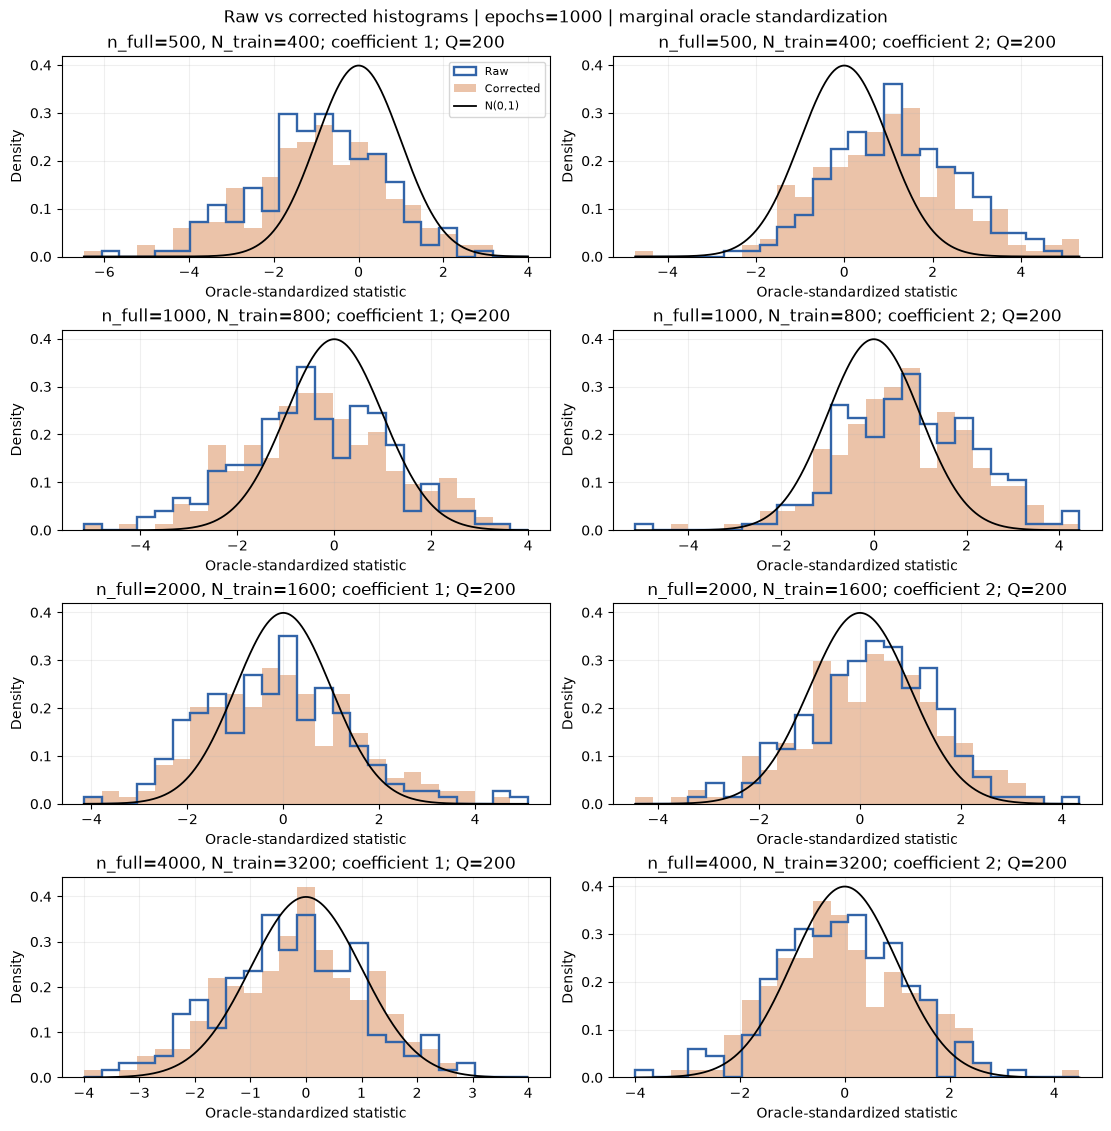

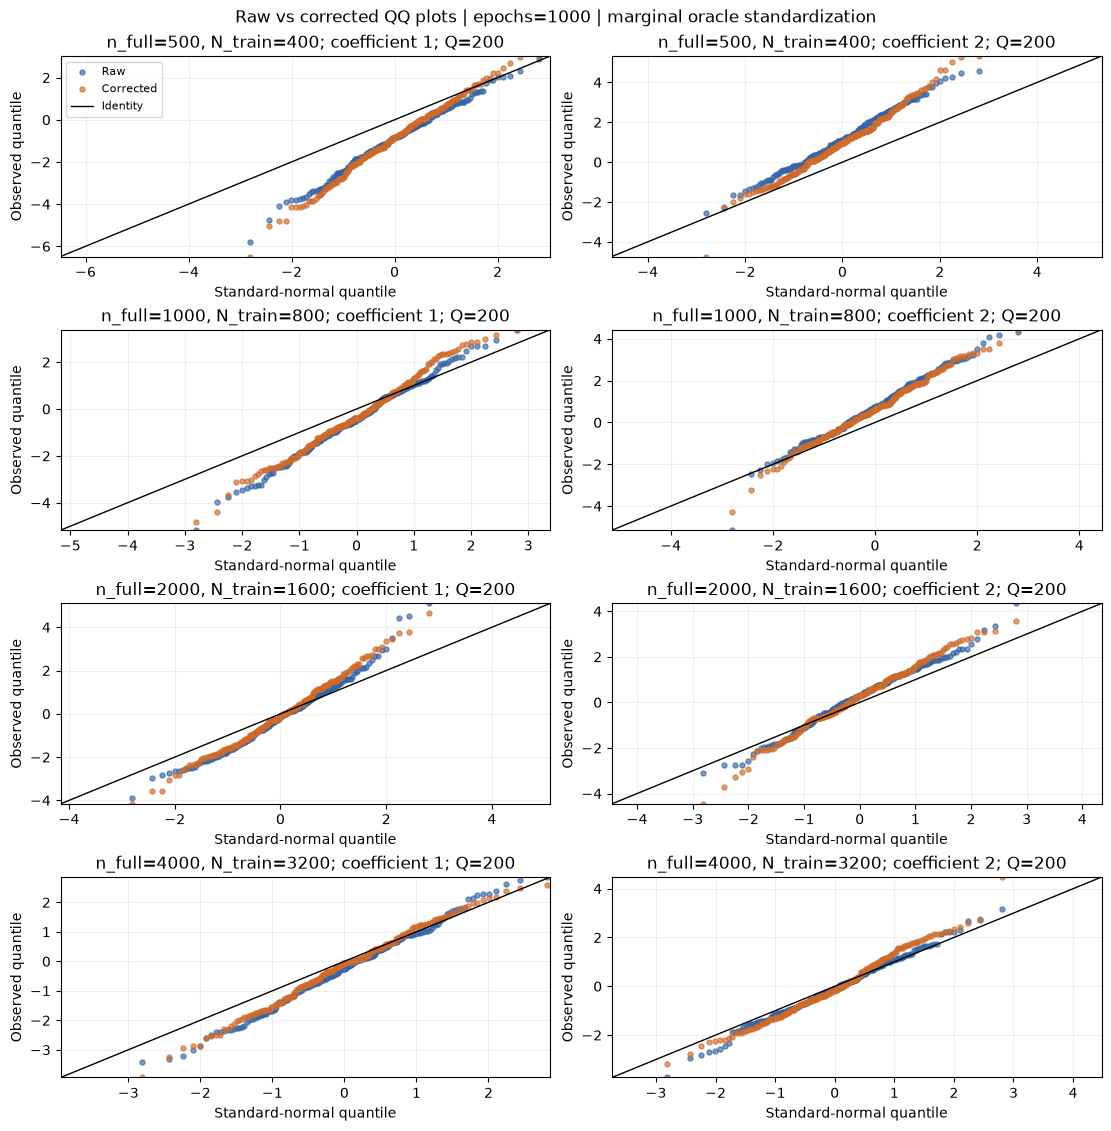

In [6]:
COLORS = {"raw": "#3264A8", "corrected": "#CF6A28"}


def plot_distributions(frame, epochs, mode):
    subset = frame.loc[frame["epochs"].eq(epochs)]
    ns = sorted(subset["n"].unique())
    if mode == "whitened":
        raw_column, corrected_column = "Z_A", "Z_C"
        description = "symmetric matrix whitening"
        coordinate_label = "whitened coordinate"
    elif mode == "marginal":
        raw_column, corrected_column = "T_A", "T_C"
        description = "marginal oracle standardization"
        coordinate_label = "coefficient"
    else:
        raise ValueError(mode)

    fig_h, axes_h = plt.subplots(len(ns), 2, figsize=(11, 2.8 * len(ns)),
                                 squeeze=False, constrained_layout=True)
    fig_q, axes_q = plt.subplots(len(ns), 2, figsize=(11, 2.8 * len(ns)),
                                 squeeze=False, constrained_layout=True)
    for row_index, n in enumerate(ns):
        for col_index, j in enumerate((1, 2)):
            group = subset.loc[subset["n"].eq(n) & subset["coefficient"].eq(j)]
            raw = group[raw_column].to_numpy()
            corrected = group[corrected_column].to_numpy()
            N, q = int(group["n_train"].iloc[0]), len(group)
            combined = np.concatenate((raw, corrected))
            span = [min(-4.0, float(combined.min())),
                    max(4.0, float(combined.max()))]
            bins = np.linspace(*span, 26)
            grid = np.linspace(*span, 600)
            title = f"n_full={n}, N_train={N}; {coordinate_label} {j}; Q={q}"

            ax = axes_h[row_index, col_index]
            ax.hist(raw, bins=bins, density=True, histtype="step", linewidth=1.7,
                    color=COLORS["raw"], label="Raw")
            ax.hist(corrected, bins=bins, density=True, alpha=0.4,
                    color=COLORS["corrected"], label="Corrected")
            ax.plot(grid, norm.pdf(grid), color="black", linewidth=1.3, label="N(0,1)")
            ax.set(title=title, xlabel="Oracle-standardized statistic", ylabel="Density")
            ax.grid(alpha=0.2)

            ax = axes_q[row_index, col_index]
            theoretical = norm.ppf((np.arange(q) + 0.5) / q)
            ax.scatter(theoretical, np.sort(raw), s=13, alpha=0.65,
                       color=COLORS["raw"], label="Raw")
            ax.scatter(theoretical, np.sort(corrected), s=13, alpha=0.65,
                       color=COLORS["corrected"], label="Corrected")
            lo = min(float(theoretical.min()), float(combined.min()))
            hi = max(float(theoretical.max()), float(combined.max()))
            ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, label="Identity")
            ax.set(title=title, xlabel="Standard-normal quantile",
                   ylabel="Observed quantile", xlim=(lo, hi), ylim=(lo, hi))
            ax.grid(alpha=0.2)

    axes_h[0, 0].legend(fontsize=8)
    axes_q[0, 0].legend(fontsize=8)
    fig_h.suptitle(f"Raw vs corrected histograms | epochs={epochs} | {description}")
    fig_q.suptitle(f"Raw vs corrected QQ plots | epochs={epochs} | {description}")
    display(fig_h)
    display(fig_q)
    plt.close(fig_h)
    plt.close(fig_q)


for epochs in sorted(results["epochs"].unique()):
    plot_distributions(results, int(epochs), mode="whitened")
    plot_distributions(results, int(epochs), mode="marginal")

## Mean scaled bias versus sample size

Compare $\overline A_N$ and $\overline C_N$ with zero; $\overline B_N$ shows the term subtracted. Error bars are approximate 95% Monte Carlo intervals for the means, not estimator confidence intervals. The horizontal axis uses the historical full-sample labels $n$; the vertical scaling always uses $\sqrt{N_{\mathrm{train}}}$.

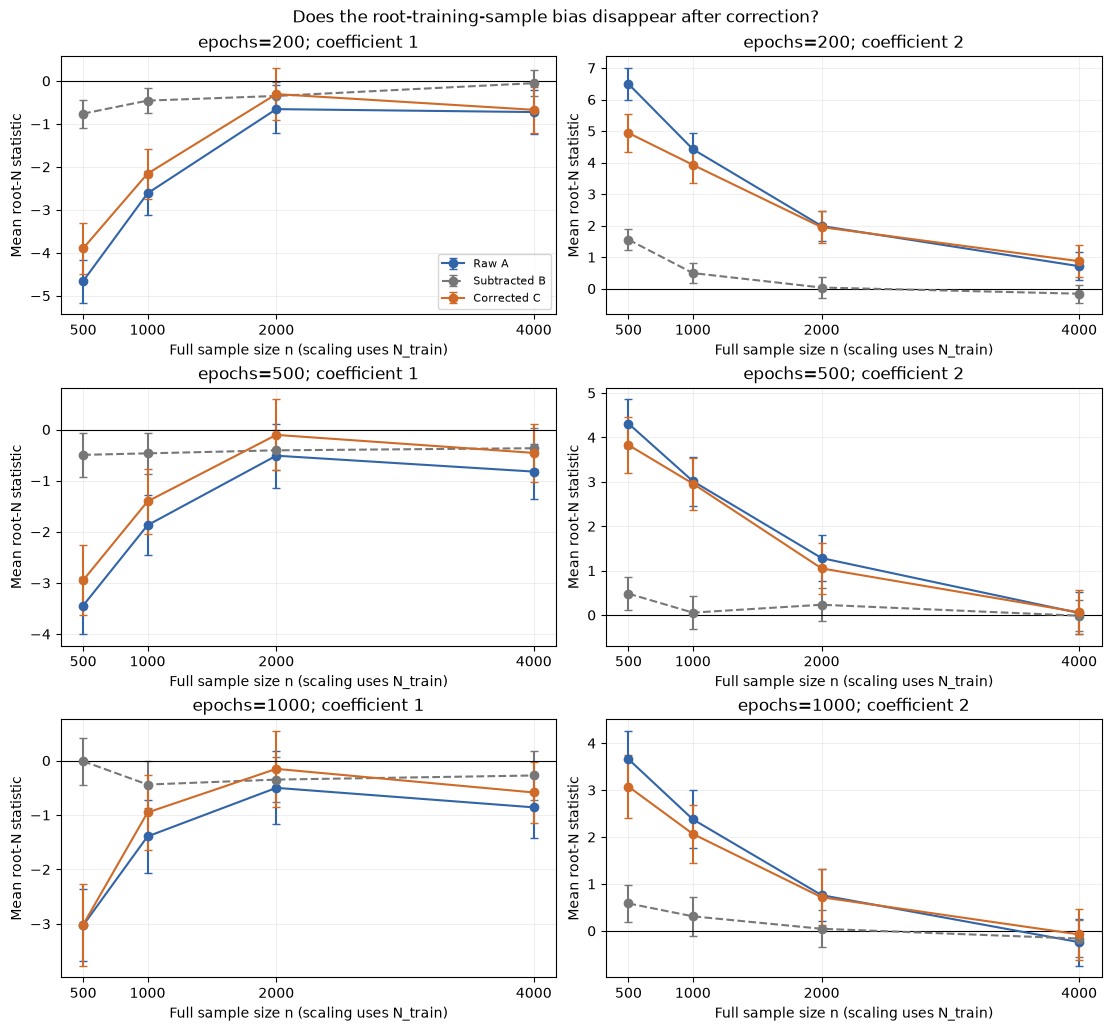

In [7]:
epoch_values = sorted(summary["epochs"].unique())
fig, axes = plt.subplots(len(epoch_values), 2, figsize=(11, 3.4 * len(epoch_values)),
                         squeeze=False, constrained_layout=True)
for row_index, epochs in enumerate(epoch_values):
    for col_index, j in enumerate((1, 2)):
        group = summary.loc[
            summary["epochs"].eq(epochs) & summary["coefficient"].eq(j)
        ].sort_values("n")
        ax = axes[row_index, col_index]
        for label, mean_col, se_col, color, linestyle in (
            ("Raw A", "mean_A", "mcse_A", COLORS["raw"], "-"),
            ("Subtracted B", "mean_B", "mcse_B", "#777777", "--"),
            ("Corrected C", "mean_C", "mcse_C", COLORS["corrected"], "-"),
        ):
            ax.errorbar(group["n"], group[mean_col],
                        yerr=CRITICAL * group[se_col], marker="o", capsize=3,
                        label=label, color=color, linestyle=linestyle)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set(title=f"epochs={epochs}; coefficient {j}",
               xlabel="Full sample size n (scaling uses N_train)",
               ylabel="Mean root-N statistic")
        ax.set_xticks(group["n"])
        ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Does the root-training-sample bias disappear after correction?")
display(fig)
plt.close(fig)

## Reading the diagnostic

Use the table, distribution plots, and bias trajectories together:

- **Bias removal:** $\overline C_N=\overline A_N-\overline B_N$ should approach zero at larger training sizes, within Monte Carlo uncertainty. Similar nonzero corrected means across the largest sizes indicate remaining scaled bias. Inspect each coefficient and epoch setting separately.
- **Normal calibration:** the corrected whitened means should be near zero and SDs near one, with histograms and identity-line QQ plots resembling $N(0,1)$. The same marginal checks connect directly to the original coefficient intervals.
- **Coverage:** corrected marginal coverage should be near 0.95, allowing for the reported Monte Carlo SE. Good shape after empirical recentering would not answer this question, which is why no such recentering is performed.
- **Possible mixed outcome:** correction may remove the mean bias while leaving an incorrect spread or tail behavior. Conversely, matching the first two moments alone does not establish a normal distribution.

The compact comparison below shows the two largest available sample sizes for each coefficient and epoch setting. It does not automatically declare success from a threshold. Finite replications can support or contradict this diagnostic at the saved settings; they cannot prove an asymptotic limit or guarantee coverage for an implementable non-oracle estimator. No empirical conclusion is asserted until the notebook is run.

In [8]:
largest_ns = sorted(summary["n"].unique())[-2:]
comparison_columns = [
    "epochs", "coefficient", "n", "n_train", "Q",
    "mean_A", "mean_B", "mean_C", "mcse_C", "sd_C",
    "mean_Z_A", "sd_Z_A", "mean_Z_C", "sd_Z_C",
    "mean_T_A", "sd_T_A", "mean_T_C", "sd_T_C",
    "coverage_raw_95", "coverage_corrected_95", "mcse_coverage_corrected",
]
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(
        summary.loc[summary["n"].isin(largest_ns), comparison_columns]
        .sort_values(["epochs", "coefficient", "n"]).round(4)
    )
print("Interpret the corrected centering, spread, QQ shape, and coverage jointly.")

,epochs,coefficient,n,n_train,Q,mean_A,mean_B,mean_C,mcse_C,sd_C,mean_Z_A,sd_Z_A,mean_Z_C,sd_Z_C,mean_T_A,sd_T_A,mean_T_C,sd_T_C,coverage_raw_95,coverage_corrected_95,mcse_coverage_corrected
4,200,1,2000,1600,200,-0.6566,-0.3498,-0.3068,0.3129,4.4255,-0.1818,1.2558,-0.0728,1.3597,-0.2038,1.2576,-0.0961,1.3629,0.860,0.855,0.0249
6,200,1,4000,3200,200,-0.7243,-0.0519,-0.6724,0.2703,3.8223,-0.2158,1.1211,-0.1998,1.1812,-0.2228,1.1194,-0.2086,1.1805,0.920,0.890,0.0221
5,200,2,2000,1600,200,1.9890,0.0369,1.9521,0.2581,3.6506,0.6298,1.0856,0.6203,1.1667,0.6376,1.0870,0.6242,1.1703,0.895,0.865,0.0242
7,200,2,4000,3200,200,0.7134,-0.1592,0.8726,0.2609,3.6901,0.2218,1.0307,0.2736,1.1813,0.2283,1.0292,0.2793,1.1808,0.955,0.870,0.0238
12,500,1,2000,1600,200,-0.5117,-0.4068,-0.1049,0.3551,5.0220,-0.1459,1.3859,-0.0240,1.5429,-0.1593,1.3884,-0.0352,1.5447,0.835,0.815,0.0275
14,500,1,4000,3200,200,-0.8227,-0.3657,-0.4570,0.2855,4.0377,-0.2538,1.2070,-0.1408,1.2469,-0.2532,1.2037,-0.1411,1.2463,0.895,0.895,0.0217
13,500,2,2000,1600,200,1.2828,0.2321,1.0507,0.2919,4.1276,0.4041,1.1752,0.3339,1.3192,0.4119,1.1773,0.3370,1.3211,0.895,0.815,0.0275
15,500,2,4000,3200,200,0.0460,-0.0153,0.0613,0.2512,3.5523,0.0060,1.0923,0.0158,1.1373,0.0145,1.0886,0.0194,1.1368,0.940,0.925,0.0186
20,1000,1,2000,1600,200,-0.5006,-0.3488,-0.1518,0.3565,5.0417,-0.1468,1.4948,-0.0417,1.5515,-0.1554,1.4956,-0.0503,1.5520,0.815,0.815,0.0275
22,1000,1,4000,3200,200,-0.8590,-0.2735,-0.5855,0.2864,4.0501,-0.2686,1.2729,-0.1826,1.2546,-0.2646,1.2677,-0.1807,1.2495,0.855,0.885,0.0226


Interpret the corrected centering, spread, QQ shape, and coverage jointly.
